# Demand Forecasting

## Demand Forecasting & Inventory Planning Analytics

This notebook develops and evaluates demand forecasting models to support inventory planning and replenishment decisions.

The analysis compares historical demand patterns, moving-average methods, exponential smoothing, and ARIMA-based forecasting.

**Workflow:** Processed Data → Demand Preparation → Historical Demand Analysis → Train/Test Split → Baseline Forecasts → Statistical Forecasting → Model Evaluation → Forecast Visualization → Future Demand Forecast → Inventory Planning Implications

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

products = pd.read_csv(
    PROCESSED_DIR / "products_clean.csv"
)

sales = pd.read_csv(
    PROCESSED_DIR / "sales_clean.csv"
)

inventory = pd.read_csv(
    PROCESSED_DIR / "inventory_clean.csv"
)

sales["order_date"] = pd.to_datetime(
    sales["order_date"]
)

inventory["date"] = pd.to_datetime(
    inventory["date"]
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data: {PROCESSED_DIR}")

print("\nDataset shapes:")
print(f"Products: {products.shape}")
print(f"Sales: {sales.shape}")
print(f"Inventory: {inventory.shape}")

Project root: c:\Users\HP 15\Documents\Supply-Chain-Data-Analysis
Processed data: c:\Users\HP 15\Documents\Supply-Chain-Data-Analysis\data\processed

Dataset shapes:
Products: (20, 7)
Sales: (7300, 7)
Inventory: (7300, 8)


In [2]:
monthly_demand = (
    sales
    .groupby(
        sales["order_date"].dt.to_period("M")
    )["quantity_ordered"]
    .sum()
    .reset_index()
)

monthly_demand["order_date"] = (
    monthly_demand["order_date"]
    .dt.to_timestamp()
)

monthly_demand = monthly_demand.rename(
    columns={
        "quantity_ordered": "demand"
    }
)

display(monthly_demand)

,order_date,demand
0,2025-01-01,22700
1,2025-02-01,24660
2,2025-03-01,26284
3,2025-04-01,24508
4,2025-05-01,22099
5,2025-06-01,22739
6,2025-07-01,22311
7,2025-08-01,21056
8,2025-09-01,21423
9,2025-10-01,22602


## 3. Historical Monthly Demand

The monthly demand series provides the time-based structure required for forecasting. The visualization helps identify changes in demand level, peaks, troughs, and potential seasonal patterns.

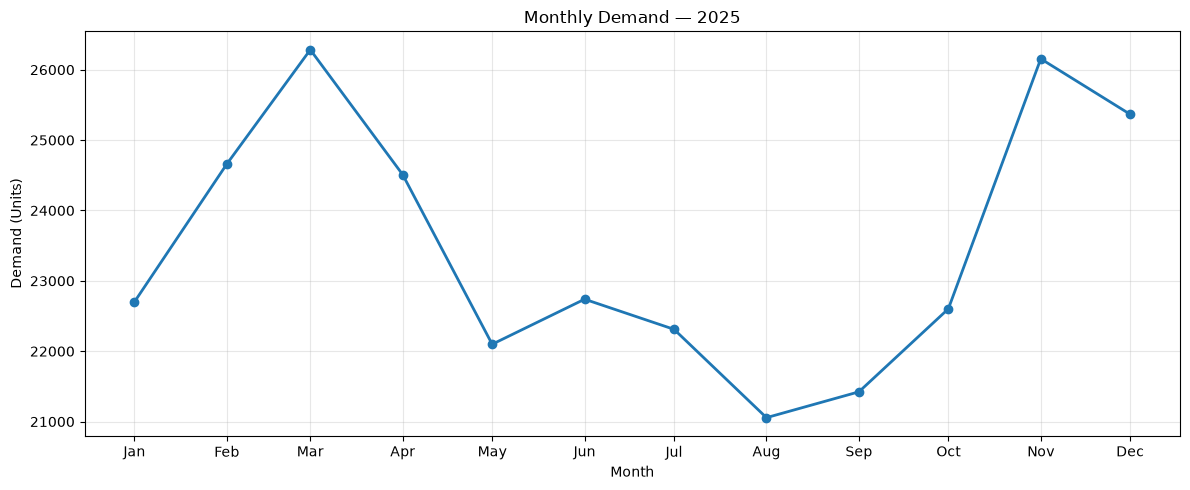

In [3]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_demand["order_date"],
    monthly_demand["demand"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Demand — 2025")
plt.xlabel("Month")
plt.ylabel("Demand (Units)")
plt.xticks(
    monthly_demand["order_date"],
    monthly_demand["order_date"].dt.strftime("%b")
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Train-Test Split

The time series is divided chronologically into training and testing periods.

The first nine months are used to train the forecasting models, while October–December are reserved as unseen test data.

A chronological split is used instead of random sampling because future observations must not be used to predict the past.

In [4]:
train = monthly_demand.iloc[:9].copy()
test = monthly_demand.iloc[9:].copy()

print("Training period:")
print(f"{train['order_date'].min():%B %Y} → {train['order_date'].max():%B %Y}")

print("\nTesting period:")
print(f"{test['order_date'].min():%B %Y} → {test['order_date'].max():%B %Y}")

print("\nObservations:")
print(f"Training: {len(train)}")
print(f"Testing: {len(test)}")

display(train)
display(test)

Training period:
January 2025 → September 2025

Testing period:
October 2025 → December 2025

Observations:
Training: 9
Testing: 3


,order_date,demand
0,2025-01-01,22700
1,2025-02-01,24660
2,2025-03-01,26284
3,2025-04-01,24508
4,2025-05-01,22099
5,2025-06-01,22739
6,2025-07-01,22311
7,2025-08-01,21056
8,2025-09-01,21423


,order_date,demand
9,2025-10-01,22602
10,2025-11-01,26155
11,2025-12-01,25366


## 5. Baseline Forecast Models

Three baseline approaches are evaluated:

1. **3-Month Moving Average (MA)** — forecasts using the average demand of the previous three months.
2. **Weighted Moving Average (WMA)** — gives greater weight to more recent demand.
3. **Simple Exponential Smoothing (SES)** — progressively reduces the influence of older observations.

These models provide benchmark forecasts against which more advanced forecasting models can be evaluated.

In [5]:
# Extract training demand
train_demand = train["demand"].to_numpy()
test_demand = test["demand"].to_numpy()

# 3-Month Moving Average
ma_window = 3

ma_forecast = np.mean(
    train_demand[-ma_window:]
)

ma_predictions = np.repeat(
    ma_forecast,
    len(test)
)

# Weighted Moving Average
weights = np.array([1, 2, 3])

wma_forecast = np.average(
    train_demand[-3:],
    weights=weights
)

wma_predictions = np.repeat(
    wma_forecast,
    len(test)
)

print(f"3-Month Moving Average Forecast: {ma_forecast:,.2f}")
print(f"Weighted Moving Average Forecast: {wma_forecast:,.2f}")

3-Month Moving Average Forecast: 21,596.67
Weighted Moving Average Forecast: 21,448.67


## 6. Simple Exponential Smoothing

Simple Exponential Smoothing (SES) produces forecasts by assigning greater influence to recent observations while progressively reducing the influence of older observations.

SES is useful as a benchmark when demand has no strong trend or seasonal structure.

In [8]:

from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Convert training demand to a clean numeric series
train_series = pd.Series(
    train["demand"].astype(float).values
)

# Fit Simple Exponential Smoothing
ses_model = SimpleExpSmoothing(
    train_series,
    initialization_method="estimated"
)

ses_fitted = ses_model.fit()

# Forecast the test period
ses_predictions = ses_fitted.forecast(
    len(test)
)

ses_predictions = np.asarray(ses_predictions)

print("SES Forecast:")

display(
    pd.DataFrame({
        "Month": test["order_date"].dt.strftime("%b %Y"),
        "SES Forecast": ses_predictions.round(2)
    })
)

SES Forecast:


,Month,SES Forecast
9,Oct 2025,21423.0
10,Nov 2025,21423.0
11,Dec 2025,21423.0


## 7. Baseline Model Evaluation

The baseline forecasts are evaluated against the October–December test data using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

Lower values indicate smaller forecasting errors.

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Actual test demand
actual = test_demand

# Calculate evaluation metrics
def evaluate_forecast(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100

    return mae, rmse, mape


# Evaluate models
ma_mae, ma_rmse, ma_mape = evaluate_forecast(
    actual,
    ma_predictions
)

wma_mae, wma_rmse, wma_mape = evaluate_forecast(
    actual,
    wma_predictions
)

ses_mae, ses_rmse, ses_mape = evaluate_forecast(
    actual,
    ses_predictions
)

# Create comparison table
baseline_results = pd.DataFrame({
    "Model": [
        "3-Month Moving Average",
        "Weighted Moving Average",
        "Simple Exponential Smoothing"
    ],
    "MAE": [
        ma_mae,
        wma_mae,
        ses_mae
    ],
    "RMSE": [
        ma_rmse,
        wma_rmse,
        ses_rmse
    ],
    "MAPE (%)": [
        ma_mape,
        wma_mape,
        ses_mape
    ]
})

baseline_results = baseline_results.sort_values(
    "MAE"
).reset_index(drop=True)

display(
    baseline_results.round(2)
)

,Model,MAE,RMSE,MAPE (%)
0,3-Month Moving Average,3111.00,3463.96,12.25
1,Weighted Moving Average,3259.00,3597.46,12.85
2,Simple Exponential Smoothing,3284.67,3620.73,12.95


## 8. ARIMA Forecasting

Autoregressive Integrated Moving Average (ARIMA) is a statistical time-series model that captures patterns in historical demand through autoregression, differencing, and moving-average error terms.

The ARIMA model is evaluated on the same October–December 2025 test period used for the baseline models.

This provides a consistent comparison between simple forecasting methods and a statistical time-series model.

In [10]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA(1,1,1) on the training demand
arima_model = ARIMA(
    train_demand,
    order=(1, 1, 1)
)

arima_fitted = arima_model.fit()

# Forecast the test period
arima_predictions = arima_fitted.forecast(
    steps=len(test)
)

arima_predictions = np.asarray(arima_predictions)

print("ARIMA(1,1,1) Forecast:")

display(
    pd.DataFrame({
        "Month": test["order_date"].dt.strftime("%b %Y"),
        "ARIMA Forecast": arima_predictions.round(2)
    })
)

ARIMA(1,1,1) Forecast:


,Month,ARIMA Forecast
9,Oct 2025,21453.16
10,Nov 2025,21460.64
11,Dec 2025,21462.50


In [11]:
# Evaluate ARIMA forecast
arima_mae, arima_rmse, arima_mape = evaluate_forecast(
    actual,
    arima_predictions
)

# Add ARIMA to the baseline results
arima_result = pd.DataFrame({
    "Model": ["ARIMA(1,1,1)"],
    "MAE": [arima_mae],
    "RMSE": [arima_rmse],
    "MAPE (%)": [arima_mape]
})

forecast_results = pd.concat(
    [baseline_results, arima_result],
    ignore_index=True
)

forecast_results = forecast_results.sort_values(
    "MAE"
).reset_index(drop=True)

display(
    forecast_results.round(2)
)

,Model,MAE,RMSE,MAPE (%)
0,3-Month Moving Average,3111.00,3463.96,12.25
1,"ARIMA(1,1,1)",3248.90,3586.74,12.81
2,Weighted Moving Average,3259.00,3597.46,12.85
3,Simple Exponential Smoothing,3284.67,3620.73,12.95


## 9. Model Evaluation Results

The four forecasting approaches were evaluated using the same October–December 2025 test period.

The 3-Month Moving Average produced the lowest MAE (3,111 units), RMSE (3,463.96 units), and MAPE (12.25%) among the models evaluated. ARIMA(1,1,1) followed with an MAE of 3,248.90 units and MAPE of 12.81%.

The relatively small difference between the models indicates that the forecasting methods perform similarly on this test period. The three-month test window is also limited, so the results should not be interpreted as evidence that one model will consistently outperform the others under different demand conditions.

For inventory planning, the selected forecasting approach should therefore be validated using additional historical periods, rolling time-series cross-validation, and operational considerations such as seasonality, lead time, safety stock, and stockout risk.

In [12]:
# Create comparison dataframe
forecast_comparison = pd.DataFrame({
    "Month": test["order_date"],
    "Actual": actual,
    "3-Month MA": ma_predictions,
    "Weighted MA": wma_predictions,
    "SES": ses_predictions,
    "ARIMA(1,1,1)": arima_predictions
})

display(forecast_comparison.round(2))

,Month,Actual,3-Month MA,Weighted MA,SES,"ARIMA(1,1,1)"
9,2025-10-01,22602,21596.67,21448.67,21423.0,21453.16
10,2025-11-01,26155,21596.67,21448.67,21423.0,21460.64
11,2025-12-01,25366,21596.67,21448.67,21423.0,21462.50


## 10. Actual vs Forecast Demand

The following visualization compares actual demand with forecasts from the four models during the October–December 2025 test period.

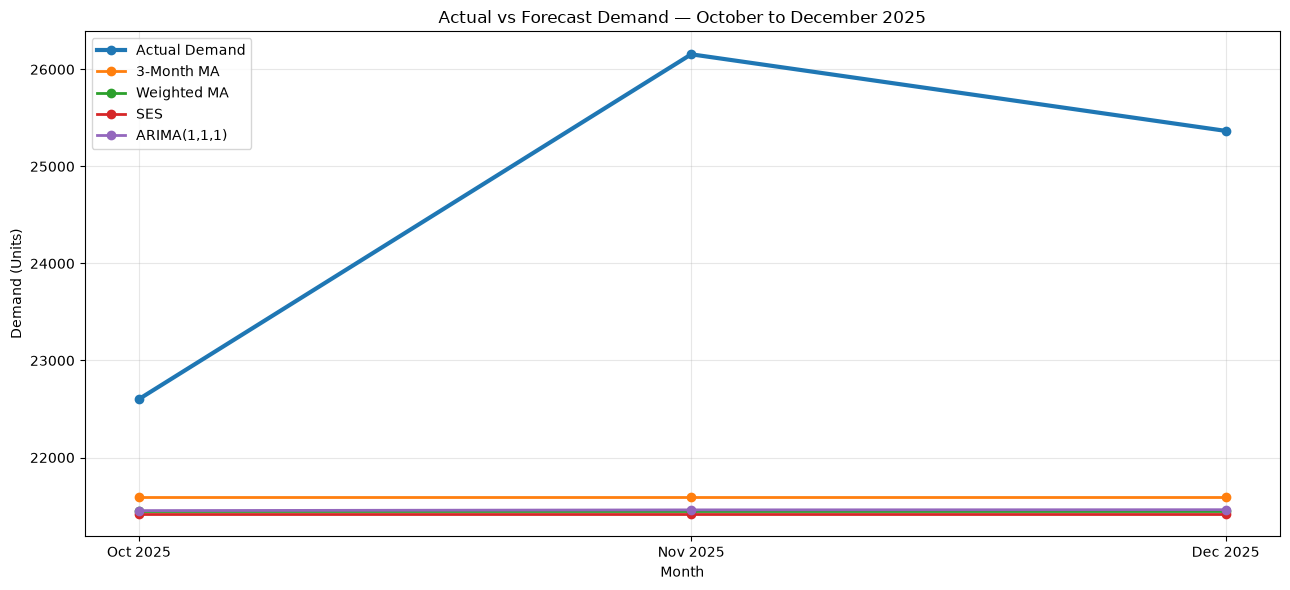

In [13]:
plt.figure(figsize=(13, 6))

plt.plot(
    forecast_comparison["Month"],
    forecast_comparison["Actual"],
    marker="o",
    linewidth=3,
    label="Actual Demand"
)

plt.plot(
    forecast_comparison["Month"],
    forecast_comparison["3-Month MA"],
    marker="o",
    linewidth=2,
    label="3-Month MA"
)

plt.plot(
    forecast_comparison["Month"],
    forecast_comparison["Weighted MA"],
    marker="o",
    linewidth=2,
    label="Weighted MA"
)

plt.plot(
    forecast_comparison["Month"],
    forecast_comparison["SES"],
    marker="o",
    linewidth=2,
    label="SES"
)

plt.plot(
    forecast_comparison["Month"],
    forecast_comparison["ARIMA(1,1,1)"],
    marker="o",
    linewidth=2,
    label="ARIMA(1,1,1)"
)

plt.title("Actual vs Forecast Demand — October to December 2025")
plt.xlabel("Month")
plt.ylabel("Demand (Units)")

plt.xticks(
    forecast_comparison["Month"],
    forecast_comparison["Month"].dt.strftime("%b %Y")
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Future Demand Forecast

After evaluating the forecasting models on the historical test period, the selected baseline model is used to generate a forward demand forecast.

The 3-Month Moving Average is used here because it produced the lowest error across MAE, RMSE, and MAPE in the October–December 2025 test period.

The forecast is extended for the next three months to demonstrate how demand forecasts can support inventory replenishment and purchasing decisions.

In [14]:
# Use the selected model: 3-Month Moving Average

historical_demand = monthly_demand["demand"].to_numpy()

future_ma_forecast = np.mean(
    historical_demand[-3:]
)

future_dates = pd.date_range(
    start=monthly_demand["order_date"].max() + pd.offsets.MonthBegin(1),
    periods=3,
    freq="MS"
)

future_forecast = pd.DataFrame({
    "Month": future_dates,
    "Forecast Demand": [
        future_ma_forecast
    ] * 3
})

display(
    future_forecast.round(2)
)

,Month,Forecast Demand
0,2026-01-01,24707.67
1,2026-02-01,24707.67
2,2026-03-01,24707.67
